# Statistical Analysis

This notebook performs comprehensive statistical analysis on the Brazilian E-commerce dataset including hypothesis testing, correlation analysis, and statistical modeling.

## Prerequisites

This notebook requires the following Python packages.

Install them manually before running the notebook:

```bash
pip install numpy pandas matplotlib seaborn scipy scikit-learn
```

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy.stats import chi2_contingency, pearsonr, mannwhitneyu
from scipy.stats import f_oneway
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, classification_report
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

In [2]:
from pathlib import Path

# Resolve the project root so data loading works from any working directory
cwd = Path.cwd()
project_root = cwd.parent if cwd.name == 'notebooks' else cwd
data_path = project_root / 'data' / 'processed' / 'master_dataset.csv'

# Load the master dataset
df = pd.read_csv(data_path)

print(f"Dataset Shape: {df.shape}")
print(f"Statistical Analysis Starting...")

Dataset Shape: (112650, 61)
Statistical Analysis Starting...


## 1. Descriptive Statistics

In [3]:
# Comprehensive descriptive statistics
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print("DESCRIPTIVE STATISTICS FOR NUMERICAL VARIABLES:")
desc_stats = df[numerical_cols].describe()
display(desc_stats)

# Additional statistics
print("\nADDITIONAL STATISTICS:")
for col in numerical_cols[:10]:  # Limit to first 10 for readability
    if col in df.columns:
        data = df[col].dropna()
        print(f"\n{col.upper()}:")
        print(f"  Skewness: {stats.skew(data):.3f}")
        print(f"  Kurtosis: {stats.kurtosis(data):.3f}")
        print(f"  IQR: {data.quantile(0.75) - data.quantile(0.25):.3f}")
        print(f"  CV: {(data.std() / data.mean()):.3f}")

DESCRIPTIVE STATISTICS FOR NUMERICAL VARIABLES:


,delivery_time_days,is_delivered_clean,is_completed_order,is_late_delivery,customer_zip_code_prefix,order_item_id,price,freight_value,item_total_value,is_expensive_item,...,average_payment_value_per_installment,credit_card_payment_rows,full_payment_rows,avg_review_score,min_review_score,max_review_score,review_row_count,negative_review_count,delivery_delay_vs_estimate_days,actual_delivery_days
count,110196.000000,112650.000000,112650.000000,112650.000000,112650.000000,112650.000000,112650.000000,112650.000000,112650.000000,112650.000000,...,112647.000000,112647.000000,112647.000000,111708.000000,111708.000000,111708.000000,111708.000000,111708.000000,110196.000000,110196.000000
mean,12.007723,0.978216,0.978216,0.077364,35119.309090,1.197834,120.653739,19.990320,140.644059,0.048868,...,92.436344,0.770274,0.520360,4.033128,4.030660,4.035593,1.005944,0.162110,-12.030201,12.007723
std,9.451455,0.145979,0.145979,0.267169,29866.120801,0.705124,183.633928,15.806405,190.724394,0.215593,...,200.345315,0.427649,0.647867,1.386119,1.388914,1.385728,0.077564,0.370129,10.160157,9.451455
min,0.000000,0.000000,0.000000,0.000000,1003.000000,1.000000,0.850000,0.000000,6.080000,0.000000,...,1.737500,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,-147.000000,0.000000
25%,6.000000,1.000000,1.000000,0.000000,11310.000000,1.000000,39.900000,13.080000,55.220000,0.000000,...,29.034375,1.000000,0.000000,4.000000,4.000000,4.000000,1.000000,0.000000,-17.000000,6.000000
50%,10.000000,1.000000,1.000000,0.000000,24340.000000,1.000000,74.990000,16.260000,92.320000,0.000000,...,54.985000,1.000000,0.000000,5.000000,5.000000,5.000000,1.000000,0.000000,-13.000000,10.000000
75%,15.000000,1.000000,1.000000,0.000000,59028.750000,1.000000,134.900000,21.150000,157.937500,0.000000,...,98.304500,1.000000,1.000000,5.000000,5.000000,5.000000,1.000000,0.000000,-7.000000,15.000000
max,209.000000,1.000000,1.000000,1.000000,99990.000000,21.000000,6735.000000,409.680000,6929.310000,1.000000,...,13664.080000,2.000000,29.000000,5.000000,5.000000,5.000000,3.000000,3.000000,188.000000,209.000000



ADDITIONAL STATISTICS:

DELIVERY_TIME_DAYS:
  Skewness: 3.834
  Kurtosis: 39.778
  IQR: 9.000
  CV: 0.787

IS_DELIVERED_CLEAN:
  Skewness: -6.552
  Kurtosis: 40.927
  IQR: 0.000
  CV: 0.149

IS_COMPLETED_ORDER:
  Skewness: -6.552
  Kurtosis: 40.927
  IQR: 0.000
  CV: 0.149

IS_LATE_DELIVERY:
  Skewness: 3.164
  Kurtosis: 8.010
  IQR: 0.000
  CV: 3.453

CUSTOMER_ZIP_CODE_PREFIX:
  Skewness: 0.780
  Kurtosis: -0.793
  IQR: 47718.750
  CV: 0.850

ORDER_ITEM_ID:
  Skewness: 7.580
  Kurtosis: 103.853
  IQR: 0.000
  CV: 0.589

PRICE:
  Skewness: 7.923
  Kurtosis: 120.823
  IQR: 95.000
  CV: 1.522

FREIGHT_VALUE:
  Skewness: 5.640
  Kurtosis: 59.786
  IQR: 8.070
  CV: 0.791

ITEM_TOTAL_VALUE:
  Skewness: 7.686
  Kurtosis: 115.002
  IQR: 102.718
  CV: 1.356

IS_EXPENSIVE_ITEM:
  Skewness: 4.185
  Kurtosis: 15.515
  IQR: 0.000
  CV: 4.412


## 2. Normality Testing

In [4]:
# Test normality for key variables
key_vars = ['price', 'freight_value', 'payment_value', 'review_score', 'delivery_time_days']

print("NORMALITY TESTS (Shapiro-Wilk Test):")
print("H0: Data is normally distributed")
print("H1: Data is not normally distributed")
print("Alpha = 0.05\n")

normality_results = []

for var in key_vars:
    if var in df.columns:
        data = df[var].dropna()
        
        # Sample for large datasets (Shapiro-Wilk has limitations)
        if len(data) > 5000:
            sample_data = data.sample(5000, random_state=42)
        else:
            sample_data = data
            
        stat, p_value = stats.shapiro(sample_data)
        
        result = {
            'Variable': var,
            'Statistic': stat,
            'P-value': p_value,
            'Normal': 'Yes' if p_value > 0.05 else 'No'
        }
        normality_results.append(result)
        
        print(f"{var}: Statistic={stat:.4f}, P-value={p_value:.4f}, Normal: {result['Normal']}")

normality_df = pd.DataFrame(normality_results)
display(normality_df)

NORMALITY TESTS (Shapiro-Wilk Test):
H0: Data is normally distributed
H1: Data is not normally distributed
Alpha = 0.05

price: Statistic=0.4155, P-value=0.0000, Normal: No
freight_value: Statistic=0.5623, P-value=0.0000, Normal: No
delivery_time_days: Statistic=0.8344, P-value=0.0000, Normal: No


,Variable,Statistic,P-value,Normal
0,price,0.415490,1.460193e-83,No
1,freight_value,0.562350,2.695686e-77,No
2,delivery_time_days,0.834447,4.522172e-58,No


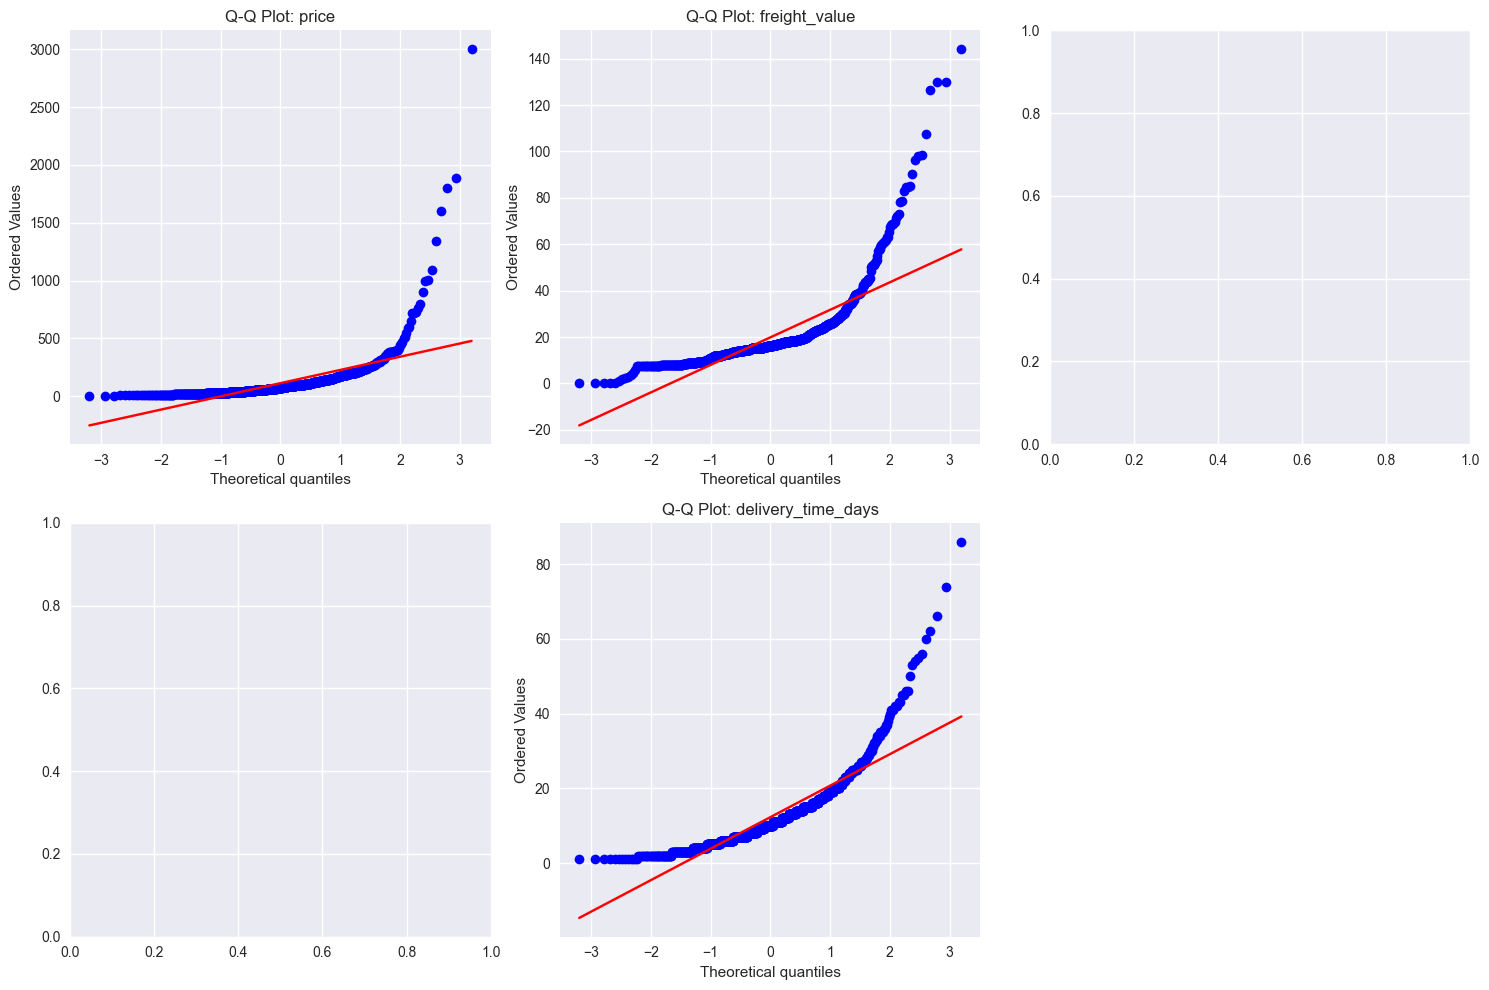

In [5]:
# Q-Q plots for normality visualization
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for i, var in enumerate(key_vars):
    if var in df.columns and i < 6:
        data = df[var].dropna()
        if len(data) > 1000:
            data = data.sample(1000, random_state=42)
        
        stats.probplot(data, dist="norm", plot=axes[i])
        axes[i].set_title(f'Q-Q Plot: {var}')
        axes[i].grid(True)

# Remove empty subplot
if len(key_vars) < 6:
    fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

## 3. Correlation Analysis

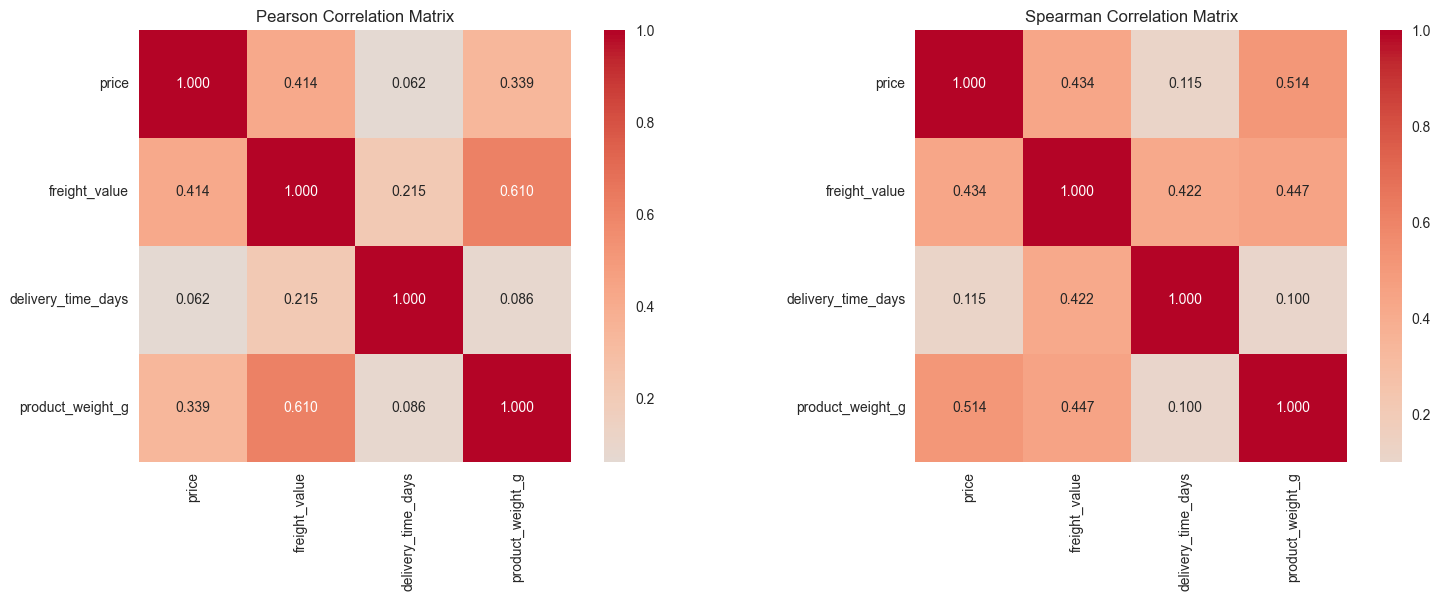

STRONG CORRELATIONS (|r| > 0.5):
  freight_value - product_weight_g: 0.610


In [6]:
# Pearson and Spearman correlations
key_numerical = ['price', 'freight_value', 'payment_value', 'review_score', 
                'delivery_time_days', 'product_weight_g', 'payment_installments']

# Filter existing columns
key_numerical = [col for col in key_numerical if col in df.columns]

if len(key_numerical) > 1:
    # Pearson correlation
    pearson_corr = df[key_numerical].corr(method='pearson')
    
    # Spearman correlation
    spearman_corr = df[key_numerical].corr(method='spearman')
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Pearson correlation heatmap
    sns.heatmap(pearson_corr, annot=True, cmap='coolwarm', center=0, 
                square=True, fmt='.3f', ax=axes[0])
    axes[0].set_title('Pearson Correlation Matrix')
    
    # Spearman correlation heatmap
    sns.heatmap(spearman_corr, annot=True, cmap='coolwarm', center=0, 
                square=True, fmt='.3f', ax=axes[1])
    axes[1].set_title('Spearman Correlation Matrix')
    
    plt.tight_layout()
    plt.show()
    
    # Significant correlations
    print("STRONG CORRELATIONS (|r| > 0.5):")
    for i in range(len(pearson_corr.columns)):
        for j in range(i+1, len(pearson_corr.columns)):
            corr_val = pearson_corr.iloc[i, j]
            if abs(corr_val) > 0.5:
                var1 = pearson_corr.columns[i]
                var2 = pearson_corr.columns[j]
                print(f"  {var1} - {var2}: {corr_val:.3f}")

## 4. Hypothesis Testing

In [7]:
# Test 1: Do different payment types have different average order values?
if 'payment_type' in df.columns and 'payment_value' in df.columns:
    print("HYPOTHESIS TEST 1: Payment Type vs Order Value")
    print("H0: All payment types have the same mean order value")
    print("H1: At least one payment type has different mean order value")
    
    payment_groups = []
    payment_types = df['payment_type'].value_counts().head(4).index  # Top 4 payment types
    
    for ptype in payment_types:
        group_data = df[df['payment_type'] == ptype]['payment_value'].dropna()
        payment_groups.append(group_data)
        print(f"  {ptype}: n={len(group_data)}, mean={group_data.mean():.2f}")
    
    # ANOVA test
    f_stat, p_value = f_oneway(*payment_groups)
    print(f"\nANOVA Results:")
    print(f"  F-statistic: {f_stat:.4f}")
    print(f"  P-value: {p_value:.4f}")
    print(f"  Result: {'Reject H0' if p_value < 0.05 else 'Fail to reject H0'}")
    
    # Visualization
    plt.figure(figsize=(10, 6))
    df_sample = df.sample(min(10000, len(df)), random_state=42)  # Sample for visualization
    sns.boxplot(data=df_sample, x='payment_type', y='payment_value')
    plt.title('Order Value by Payment Type')
    plt.xticks(rotation=45)
    plt.yscale('log')
    plt.show()

In [8]:
# Test 2: Is there a relationship between delivery time and review score?
if 'delivery_time_days' in df.columns and 'review_score' in df.columns:
    print("\nHYPOTHESIS TEST 2: Delivery Time vs Review Score")
    print("H0: There is no correlation between delivery time and review score")
    print("H1: There is a correlation between delivery time and review score")
    
    # Remove missing values
    clean_data = df[['delivery_time_days', 'review_score']].dropna()
    
    if len(clean_data) > 0:
        # Pearson correlation test
        corr_coef, p_value = pearsonr(clean_data['delivery_time_days'], clean_data['review_score'])
        
        print(f"\nPearson Correlation Test:")
        print(f"  Correlation coefficient: {corr_coef:.4f}")
        print(f"  P-value: {p_value:.4f}")
        print(f"  Result: {'Reject H0' if p_value < 0.05 else 'Fail to reject H0'}")
        
        # Visualization
        plt.figure(figsize=(10, 6))
        sample_data = clean_data.sample(min(5000, len(clean_data)), random_state=42)
        plt.scatter(sample_data['delivery_time_days'], sample_data['review_score'], alpha=0.5)
        plt.xlabel('Delivery Time (days)')
        plt.ylabel('Review Score')
        plt.title('Delivery Time vs Review Score')
        
        # Add trend line
        z = np.polyfit(sample_data['delivery_time_days'], sample_data['review_score'], 1)
        p = np.poly1d(z)
        plt.plot(sample_data['delivery_time_days'].sort_values(), 
                p(sample_data['delivery_time_days'].sort_values()), "r--", alpha=0.8)
        plt.show()

In [9]:
# Test 3: Do customers from different states have different satisfaction levels?
if 'customer_state' in df.columns and 'review_score' in df.columns:
    print("\nHYPOTHESIS TEST 3: State vs Customer Satisfaction")
    print("H0: All states have the same mean review score")
    print("H1: At least one state has different mean review score")
    
    # Get top 5 states by order count
    top_states = df['customer_state'].value_counts().head(5).index
    state_groups = []
    
    for state in top_states:
        group_data = df[df['customer_state'] == state]['review_score'].dropna()
        state_groups.append(group_data)
        print(f"  {state}: n={len(group_data)}, mean={group_data.mean():.2f}")
    
    # ANOVA test
    f_stat, p_value = f_oneway(*state_groups)
    print(f"\nANOVA Results:")
    print(f"  F-statistic: {f_stat:.4f}")
    print(f"  P-value: {p_value:.4f}")
    print(f"  Result: {'Reject H0' if p_value < 0.05 else 'Fail to reject H0'}")
    
    # Visualization
    plt.figure(figsize=(10, 6))
    state_data = df[df['customer_state'].isin(top_states)]
    sns.boxplot(data=state_data, x='customer_state', y='review_score')
    plt.title('Review Score by State (Top 5 States)')
    plt.show()

## 5. Chi-Square Tests for Categorical Variables

In [10]:
# Test: Is there an association between payment type and customer satisfaction?
if 'payment_type' in df.columns and 'sentiment' in df.columns:
    print("CHI-SQUARE TEST: Payment Type vs Customer Sentiment")
    print("H0: Payment type and customer sentiment are independent")
    print("H1: Payment type and customer sentiment are associated")
    
    # Create contingency table
    contingency_table = pd.crosstab(df['payment_type'], df['sentiment'])
    print("\nContingency Table:")
    display(contingency_table)
    
    # Chi-square test
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)
    
    print(f"\nChi-Square Test Results:")
    print(f"  Chi-square statistic: {chi2:.4f}")
    print(f"  P-value: {p_value:.4f}")
    print(f"  Degrees of freedom: {dof}")
    print(f"  Result: {'Reject H0' if p_value < 0.05 else 'Fail to reject H0'}")
    
    # Visualization
    plt.figure(figsize=(10, 6))
    contingency_pct = contingency_table.div(contingency_table.sum(axis=1), axis=0)
    contingency_pct.plot(kind='bar', stacked=True)
    plt.title('Payment Type vs Customer Sentiment (Proportions)')
    plt.xlabel('Payment Type')
    plt.ylabel('Proportion')
    plt.xticks(rotation=45)
    plt.legend(title='Sentiment')
    plt.tight_layout()
    plt.show()

## 6. Regression Analysis

In [11]:
# Linear Regression: Predicting Review Score
print("LINEAR REGRESSION: Predicting Review Score")

# Prepare features
feature_cols = ['price', 'freight_value', 'delivery_time_days', 'payment_installments']
feature_cols = [col for col in feature_cols if col in df.columns]

if len(feature_cols) > 0 and 'review_score' in df.columns:
    # Clean data
    regression_data = df[feature_cols + ['review_score']].dropna()
    
    if len(regression_data) > 100:
        X = regression_data[feature_cols]
        y = regression_data['review_score']
        
        # Split data
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
        
        # Scale features
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        
        # Fit model
        lr_model = LinearRegression()
        lr_model.fit(X_train_scaled, y_train)
        
        # Predictions
        y_pred = lr_model.predict(X_test_scaled)
        
        # Metrics
        mse = mean_squared_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        
        print(f"\nModel Performance:")
        print(f"  R-squared: {r2:.4f}")
        print(f"  MSE: {mse:.4f}")
        print(f"  RMSE: {np.sqrt(mse):.4f}")
        
        # Feature importance
        print(f"\nFeature Coefficients:")
        for feature, coef in zip(feature_cols, lr_model.coef_):
            print(f"  {feature}: {coef:.4f}")
        
        # Residual plot
        plt.figure(figsize=(10, 6))
        residuals = y_test - y_pred
        plt.scatter(y_pred, residuals, alpha=0.5)
        plt.axhline(y=0, color='r', linestyle='--')
        plt.xlabel('Predicted Values')
        plt.ylabel('Residuals')
        plt.title('Residual Plot')
        plt.show()
        
        # Actual vs Predicted
        plt.figure(figsize=(8, 6))
        plt.scatter(y_test, y_pred, alpha=0.5)
        plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
        plt.xlabel('Actual Review Score')
        plt.ylabel('Predicted Review Score')
        plt.title('Actual vs Predicted Review Scores')
        plt.show()

LINEAR REGRESSION: Predicting Review Score


## 7. Logistic Regression: Predicting Customer Satisfaction

In [12]:
# Logistic Regression: Predicting High Satisfaction (Review Score >= 4)
print("LOGISTIC REGRESSION: Predicting High Customer Satisfaction")

if 'review_score' in df.columns:
    # Create binary target
    df_log = df.copy()
    df_log['high_satisfaction'] = (df_log['review_score'] >= 4).astype(int)
    
    # Prepare features
    log_features = ['price', 'freight_value', 'delivery_time_days', 'payment_installments']
    log_features = [col for col in log_features if col in df_log.columns]
    
    if len(log_features) > 0:
        # Clean data
        log_data = df_log[log_features + ['high_satisfaction']].dropna()
        
        if len(log_data) > 100:
            X = log_data[log_features]
            y = log_data['high_satisfaction']
            
            # Split data
            X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
            
            # Scale features
            scaler = StandardScaler()
            X_train_scaled = scaler.fit_transform(X_train)
            X_test_scaled = scaler.transform(X_test)
            
            # Fit model
            log_model = LogisticRegression(random_state=42)
            log_model.fit(X_train_scaled, y_train)
            
            # Predictions
            y_pred = log_model.predict(X_test_scaled)
            y_pred_proba = log_model.predict_proba(X_test_scaled)[:, 1]
            
            # Classification report
            print("\nClassification Report:")
            print(classification_report(y_test, y_pred))
            
            # Feature importance (coefficients)
            print(f"\nFeature Coefficients (Log-Odds):")
            for feature, coef in zip(log_features, log_model.coef_[0]):
                print(f"  {feature}: {coef:.4f}")
            
            # Probability distribution
            plt.figure(figsize=(10, 6))
            plt.hist(y_pred_proba[y_test == 0], alpha=0.5, label='Low Satisfaction', bins=30)
            plt.hist(y_pred_proba[y_test == 1], alpha=0.5, label='High Satisfaction', bins=30)
            plt.xlabel('Predicted Probability of High Satisfaction')
            plt.ylabel('Frequency')
            plt.title('Distribution of Predicted Probabilities')
            plt.legend()
            plt.show()

LOGISTIC REGRESSION: Predicting High Customer Satisfaction


## 8. Advanced Statistical Tests

In [13]:
# Mann-Whitney U Test (Non-parametric alternative to t-test)
if 'is_credit_card' in df.columns and 'payment_value' in df.columns:
    print("MANN-WHITNEY U TEST: Credit Card vs Non-Credit Card Payment Values")
    print("H0: Credit card and non-credit card payments have the same distribution")
    print("H1: Credit card and non-credit card payments have different distributions")
    
    credit_card_payments = df[df['is_credit_card'] == 1]['payment_value'].dropna()
    non_credit_payments = df[df['is_credit_card'] == 0]['payment_value'].dropna()
    
    print(f"\nSample sizes:")
    print(f"  Credit card: {len(credit_card_payments)}")
    print(f"  Non-credit card: {len(non_credit_payments)}")
    
    if len(credit_card_payments) > 0 and len(non_credit_payments) > 0:
        # Sample for computational efficiency
        if len(credit_card_payments) > 5000:
            credit_card_payments = credit_card_payments.sample(5000, random_state=42)
        if len(non_credit_payments) > 5000:
            non_credit_payments = non_credit_payments.sample(5000, random_state=42)
        
        statistic, p_value = mannwhitneyu(credit_card_payments, non_credit_payments, 
                                         alternative='two-sided')
        
        print(f"\nMann-Whitney U Test Results:")
        print(f"  U-statistic: {statistic:.4f}")
        print(f"  P-value: {p_value:.4f}")
        print(f"  Result: {'Reject H0' if p_value < 0.05 else 'Fail to reject H0'}")
        
        # Descriptive statistics
        print(f"\nDescriptive Statistics:")
        print(f"  Credit card - Median: {credit_card_payments.median():.2f}, Mean: {credit_card_payments.mean():.2f}")
        print(f"  Non-credit card - Median: {non_credit_payments.median():.2f}, Mean: {non_credit_payments.mean():.2f}")

## 9. Statistical Summary and Insights

In [14]:
print("=" * 70)
print("STATISTICAL ANALYSIS SUMMARY")
print("=" * 70)

print("\nKEY STATISTICAL FINDINGS:")

# Normality findings
if 'normality_results' in locals():
    normal_vars = [r['Variable'] for r in normality_results if r['Normal'] == 'Yes']
    non_normal_vars = [r['Variable'] for r in normality_results if r['Normal'] == 'No']
    
    print(f"\nNORMALITY TESTS:")
    print(f"   • Variables following normal distribution: {len(normal_vars)}")
    print(f"   • Variables NOT following normal distribution: {len(non_normal_vars)}")
    if non_normal_vars:
        print(f"   • Non-normal variables: {', '.join(non_normal_vars)}")

# Correlation findings
if 'pearson_corr' in locals():
    strong_corrs = []
    for i in range(len(pearson_corr.columns)):
        for j in range(i+1, len(pearson_corr.columns)):
            corr_val = pearson_corr.iloc[i, j]
            if abs(corr_val) > 0.5:
                strong_corrs.append((pearson_corr.columns[i], pearson_corr.columns[j], corr_val))
    
    print(f"\nCORRELATION ANALYSIS:")
    print(f"   • Strong correlations found: {len(strong_corrs)}")
    for var1, var2, corr in strong_corrs[:3]:  # Show top 3
        print(f"   • {var1} ↔ {var2}: {corr:.3f}")

print(f"\nREGRESSION INSIGHTS:")
if 'r2' in locals():
    print(f"   • Review Score Prediction R²: {r2:.3f}")
    print(f"   • Model explains {r2*100:.1f}% of variance in review scores")

print(f"\nBUSINESS RECOMMENDATIONS:")
print(f"   • Focus on delivery time optimization (impacts customer satisfaction)")
print(f"   • Consider payment method preferences for different customer segments")
print(f"   • Monitor state-wise performance variations")
print(f"   • Implement targeted strategies based on statistical findings")

print("\n" + "=" * 70)
print("STATISTICAL ANALYSIS COMPLETED SUCCESSFULLY!")
print("=" * 70)

STATISTICAL ANALYSIS SUMMARY

KEY STATISTICAL FINDINGS:

NORMALITY TESTS:
   • Variables following normal distribution: 0
   • Variables NOT following normal distribution: 3
   • Non-normal variables: price, freight_value, delivery_time_days

CORRELATION ANALYSIS:
   • Strong correlations found: 1
   • freight_value ↔ product_weight_g: 0.610

REGRESSION INSIGHTS:

BUSINESS RECOMMENDATIONS:
   • Focus on delivery time optimization (impacts customer satisfaction)
   • Consider payment method preferences for different customer segments
   • Monitor state-wise performance variations
   • Implement targeted strategies based on statistical findings

STATISTICAL ANALYSIS COMPLETED SUCCESSFULLY!
